In [2]:
!pip install optuna -q

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 26.6 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

base_dir = '/content/drive/MyDrive/railway_tracks'

In [5]:
def create_dataframe(split_name):
    split_dir = os.path.join(base_dir, split_name)
    filepaths, labels, class_names = [], [], []
    classes = ['Defective', 'Non_defective']

    for cls in classes:
        class_path = os.path.join(split_dir, cls)
        if os.path.exists(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    filepaths.append(os.path.join(class_path, img_name))
                    labels.append(1 if cls == 'Defective' else 0)
                    class_names.append(cls)

    df = pd.DataFrame({'Filepath': filepaths, 'Class_Name': class_names, 'Label': labels})
    return df.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle data

# Create DataFrames
train_df = create_dataframe('Train')
val_df = create_dataframe('Validation')
test_df = create_dataframe('Test')

print(f"Total Training Images Ready: {len(train_df)}")
print(f"Total Validation Images Ready: {len(val_df)}")
print(f"Total Test Images Ready: {len(test_df)}")

Total Training Images Ready: 501
Total Validation Images Ready: 62
Total Test Images Ready: 22


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. Training Generator (WITH Fast Online Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. Validation & Test Generator (NO Augmentation, just scaling)
test_val_datagen = ImageDataGenerator(rescale=1./255)

# 3. Connect to DataFrames
print("Setting up Training Belt:")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='Filepath', y_col='Class_Name',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
)

print("\nSetting up Validation Belt:")
val_generator = test_val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='Filepath', y_col='Class_Name',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

print("\nSetting up Test Belt:")
test_generator = test_val_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='Filepath', y_col='Class_Name',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

Setting up Training Belt:
Found 501 validated image filenames belonging to 2 classes.

Setting up Validation Belt:
Found 62 validated image filenames belonging to 2 classes.

Setting up Test Belt:
Found 22 validated image filenames belonging to 2 classes.


In [7]:
import optuna
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

print("Starting Optuna Hyperparameter Search...")

def objective(trial):
    # 1. Let Optuna pick the parameters for this trial
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)

    # 2. Build the Transfer Learning Model
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False # Freeze the base model!

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # 3. Train for just 3 epochs to test the parameters quickly
    # verbose=0 keeps the output clean so it doesn't flood your screen
    history = model.fit(train_generator, epochs=3, validation_data=val_generator, verbose=0)

    # 4. Tell Optuna how well it did
    return history.history['val_accuracy'][-1]

# Create the study and tell it to maximize the accuracy
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print("\n--- OPTUNA SEARCH COMPLETE ---")
print(f"Best Validation Accuracy during search: {study.best_value * 100:.2f}%")
print("Best Hyperparameters Found:")
best_params = study.best_params
for key, value in best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-21 01:07:05,340] A new study created in memory with name: no-name-78bb9554-e83f-4487-8824-3af6339dab08


Starting Optuna Hyperparameter Search...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


[I 2026-06-21 01:18:49,275] Trial 0 finished with value: 0.6774193644523621 and parameters: {'learning_rate': 0.00011852442502811557, 'dense_units': 64, 'dropout_rate': 0.38935662157644524}. Best is trial 0 with value: 0.6774193644523621.
[I 2026-06-21 01:23:03,606] Trial 1 finished with value: 0.7580645084381104 and parameters: {'learning_rate': 0.000339640447014806, 'dense_units': 128, 'dropout_rate': 0.4215990678052516}. Best is trial 1 with value: 0.7580645084381104.
[I 2026-06-21 01:27:08,285] Trial 2 finished with value: 0.7419354915618896 and parameters: {'learning_rate': 0.002371888979124622, 'dense_units': 64, 'dropout_rate': 0.336767323820184}. Best is trial 1 with value: 0.7580645084381104.
[I 2026-06-21 01:31:11,923] Trial 3 finished with value: 0.6290322542190552 and parameters: {'learning_rate': 0.00019402690134559357, 'dense_units': 64, 'dropout_rate': 0.4051773060397723}. Best is trial 1 with value: 0.7580645084381104.
[I 2026-06-21 01:35:12,294] Trial 4 finished with v


--- OPTUNA SEARCH COMPLETE ---
Best Validation Accuracy during search: 75.81%
Best Hyperparameters Found:
  learning_rate: 0.000339640447014806
  dense_units: 128
  dropout_rate: 0.4215990678052516


In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("Building final model with Optuna's best parameters...")

# 1. Rebuild the frozen base model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# 2. Build the final architecture using Optuna's exact numbers
final_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(best_params['dense_units'], activation='relu'),
    Dropout(best_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])

# 3. Compile with Optuna's exact learning rate
final_model.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Set up safety nets (Callbacks)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5, # Stop if validation loss doesn't improve for 5 epochs
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    filepath='best_railway_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

# 5. Train for real!
print("Training the Final Model for up to 20 epochs...")
history = final_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

Building final model with Optuna's best parameters...
Training the Final Model for up to 20 epochs...
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 100s 6s/step - accuracy: 0.6786 - loss: 0.6678 - val_accuracy: 0.7581 - val_loss: 0.5297
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 68s 4s/step - accuracy: 0.7385 - loss: 0.5154 - val_accuracy: 0.8065 - val_loss: 0.4793
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.7745 - loss: 0.4654 - val_accuracy: 0.7419 - val_loss: 0.5523
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 69s 4s/step - accuracy: 0.8004 - loss: 0.4280 - val_accuracy: 0.7903 - val_loss: 0.4803
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 69s 4s/step - accuracy: 0.8224 - loss: 0.3999 - val_accuracy: 0.7581 - val_loss: 0.4501
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.8283 - loss: 0.3652 - val_accuracy: 0.7581 - val_loss: 0.4588
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 68s 4s/step - accuracy: 0.8423 - loss: 0.3533 - val_accuracy: 0.8065 - val_loss: 0.5017
Epoch 8/20
16/1

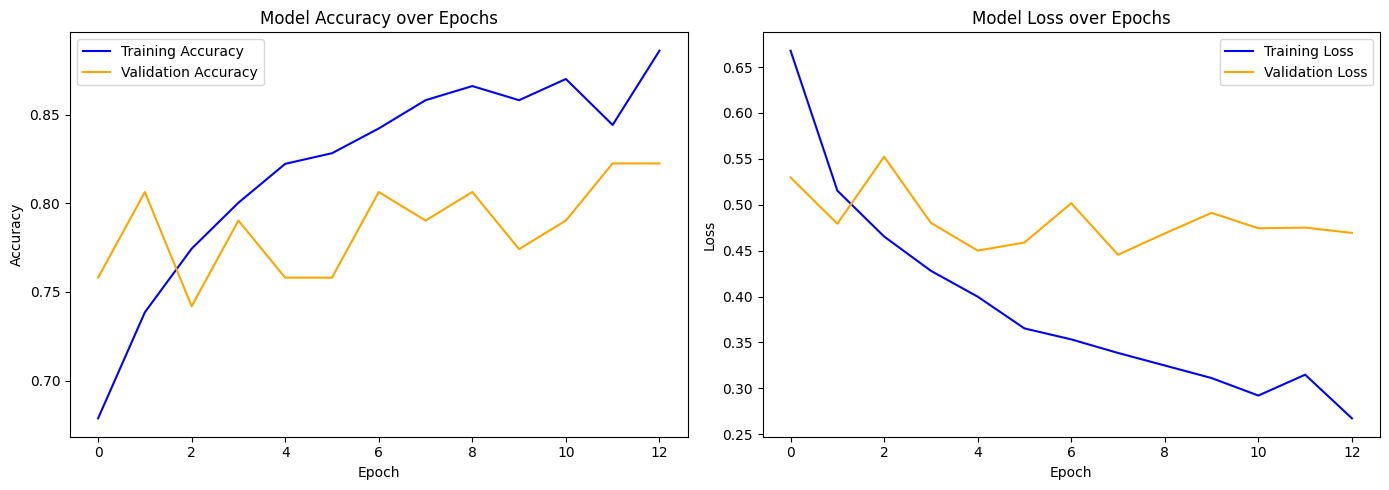


--- FINAL TEST SET EVALUATION ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.8182 - loss: 0.4629

Official Final Test Accuracy: 81.82%

Generating final predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


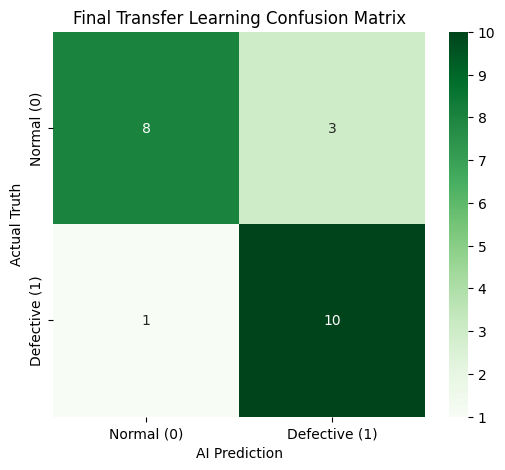


--- FINAL CLASSIFICATION REPORT ---

              precision    recall  f1-score   support

      Normal       0.89      0.73      0.80        11
   Defective       0.77      0.91      0.83        11

    accuracy                           0.82        22
   macro avg       0.83      0.82      0.82        22
weighted avg       0.83      0.82      0.82        22



In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Plot Training History (Accuracy and Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

# 2. Evaluate on Blind Test Set
print("\n--- FINAL TEST SET EVALUATION ---")
test_loss, test_accuracy = final_model.evaluate(test_generator)
print(f"\nOfficial Final Test Accuracy: {test_accuracy * 100:.2f}%\n")

# 3. Generate Predictions for the Confusion Matrix
test_generator.reset() # Reset to ensure perfect alignment
print("Generating final predictions...")
predictions = final_model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).reshape(-1)
y_true = test_generator.classes

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal (0)', 'Defective (1)'],
            yticklabels=['Normal (0)', 'Defective (1)'])
plt.title('Final Transfer Learning Confusion Matrix')
plt.ylabel('Actual Truth')
plt.xlabel('AI Prediction')
plt.show()

# 5. Print Classification Report
print("\n--- FINAL CLASSIFICATION REPORT ---\n")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Defective']))